In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder, OneHotEncoder
import keras
from keras.layers import Input, Dense
from keras.models import Model
import tensorflow as tf
from keras.callbacks import History
from keras.callbacks import CSVLogger
from sklearn.model_selection import train_test_split

2025-02-28 10:23:30.215862: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-28 10:23:30.916560: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-28 10:23:30.916599: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-28 10:23:31.445389: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-28 10:23:31.514780: I tensorflow/core/platform/cpu_feature_guar

## fix time coordinate

In [2]:
def help_adding_year(yr):
    """
    Update year string by adding one and return string.
    Args:
        yr (str): year
    """
    assert len(yr) == 4, 'year string is not correct length!'
    newyr = int(yr) + 1
    newyr = str(newyr)
    newyr = newyr.zfill(4)
    return newyr


def convert_mo_str(mo):
    """
    Convert integer month to two-digit month string.
    Args:
        mo (int): month
    """
    assert type(mo) is int, 'not an integer'
    return str(mo).zfill(2)


def help_updating_time(mo, yr):
    """
    Updating the month and year in cftime due to february start in cesm.
    Year and month (if december) are fixed.
    Args:
        mo (str): xarray filename
        yr (str): xarray filename
    """
    newmo = int(mo) + 1
    if newmo == 13:
        yr = help_adding_year(yr)
        newmo = 1
    assert newmo <= 12, 'month is greater than 12, there is an error!'
    newmo = convert_mo_str(newmo)
    return newmo, yr


def fixtime(ds):
    """
    Open file and add time coordinate.
    Args:
        ds (xarray dataset)
    """
    # start date range preprocessing
    mo0 = ds.encoding['source'].split('/')[-1].split('.')[-2][4:6]
    yr0 = ds.encoding['source'].split('/')[-1].split('.')[-2][:4]
    nm0, ny0 = help_updating_time(mo0, yr0)
    # end date range preprocessing
    yr1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-6:-2]
    mo1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-2:]
    nm1, ny1 = help_updating_time(mo1, yr1)
    # create datetime array in cftime
    newtime = xr.cftime_range(
        start=ny0+'-'+nm0+'-01',
        end=ny1+'-'+nm1+'-01',
        freq='MS',
        calendar='noleap'
    )
    ds = ds.assign_coords(time=newtime)
    return ds

## data exploration

In [3]:
#ds = xr.open_dataset('/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/atm/proc/tseries/month_1/v2.FV1.piControl.eam.h0.FLNT.000101-010012.nc')

In [4]:
#ds

In [5]:
#ds = xr.open_dataset('/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/atm/proc/tseries/month_1/v2.FV1.piControl.eam.h0.FLNTC.000101-010012.nc')

In [6]:
#ds

## Concatenate Files and fix start time

In [7]:
olr = xr.open_mfdataset(
    '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/atm/proc/tseries/month_1/v2.FV1.piControl.eam.h0.FLNT.*.nc',
    preprocess=fixtime,
    concat_dim='time',
    combine='nested'
)

In [8]:
olr

<xarray.Dataset> Size: 4GB
Dimensions:              (time: 6000, lat: 192, nbnd: 2, lon: 288, cosp_ht: 40,
                          cosp_htmisr: 16, cosp_prs: 7, cosp_reffice: 6,
                          cosp_reffliq: 6, cosp_sr: 15, cosp_tau: 7,
                          cosp_tau_modis: 7, ilev: 73, lev: 72, cosp_scol: 10,
                          cosp_sza: 5)
Coordinates: (12/15)
  * lat                  (lat) float64 2kB -90.0 -89.06 -88.12 ... 89.06 90.0
  * lon                  (lon) float64 2kB 0.0 1.25 2.5 ... 356.2 357.5 358.8
  * cosp_ht              (cosp_ht) float64 320B 1.896e+04 1.848e+04 ... 240.0
  * cosp_htmisr          (cosp_htmisr) float64 128B 0.0 250.0 ... 1.8e+04
  * cosp_prs             (cosp_prs) float64 56B 9e+04 7.4e+04 ... 2.45e+04 9e+03
  * cosp_reffice         (cosp_reffice) float64 48B 5e-06 1.5e-05 ... 7.5e-05
    ...                   ...
  * cosp_sza             (cosp_sza) float64 40B 0.0 20.0 40.0 60.0 80.0
  * cosp_tau             (cosp_tau) float64 56B 0.15 0.8 2.45 ... 41.5 100.0
  * cosp_tau_modis       (cosp_tau_modis) float64 56B 0.15 0.8 ... 41.5 100.0
  * ilev                 (ilev) float64 584B 0.1 0.1477 0.218 ... 997.0 1e+03
  * lev                  (lev) float64 576B 0.1238 0.1828 0.2699 ... 993.8 998.5
  * time                 (time) object 48kB 0001-02-01 00:00:00 ... 0501-01-0...
Dimensions without coordinates: nbnd
Data variables: (12/37)
    lat_bnds             (time, lat, nbnd) float64 18MB dask.array<chunksize=(1200, 192, 2), meta=np.ndarray>
    lon_bnds             (time, lon, nbnd) float64 28MB dask.array<chunksize=(1200, 288, 2), meta=np.ndarray>
    gw                   (time, lat) float64 9MB dask.array<chunksize=(1200, 192), meta=np.ndarray>
    area                 (time, lat, lon) float64 3GB dask.array<chunksize=(1200, 192, 288), meta=np.ndarray>
    P0                   (time) float64 48kB 1e+05 1e+05 1e+05 ... 1e+05 1e+05
    cosp_ht_bnds         (time, cosp_ht, nbnd) float64 4MB dask.array<chunksize=(1200, 40, 2), meta=np.ndarray>
    ...                   ...
    nscur                (time) int32 24kB dask.array<chunksize=(1024,), meta=np.ndarray>
    nsteph               (time) int32 24kB dask.array<chunksize=(1024,), meta=np.ndarray>
    sol_tsi              (time) float64 48kB dask.array<chunksize=(512,), meta=np.ndarray>
    time_bnds            (time, nbnd) object 96kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_written         (time) |S8 48kB dask.array<chunksize=(1,), meta=np.ndarray>
    FLNT                 (time, lat, lon) float32 1GB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes: (12/26)
    ne:                        30
    fv_nphys:                  2
    title:                     EAM History file information
    source:                    E3SM Atmosphere Model
    source_id:                 96c3ee8f6d
    product:                   model-output
    ...                        ...
    remap_hostname:            nid006377
    remap_version:             5.0.1
    NCO:                       netCDF Operators version 5.0.1 (Homepage = htt...
    nco_openmp_thread_number:  2
    map_file:                  /global/u2/s/strandwg/proj/proc/2E3SM/map_ne30...
    input_file:                /pscratch/sd/s/strandwg/E3SMv2/v2.LR.piControl...

In [9]:
olr = olr.assign_coords(
    time= olr['time'] - xr.coding.cftime_offsets.MonthBegin(1)
)

In [10]:
olr

<xarray.Dataset> Size: 4GB
Dimensions:              (time: 6000, lat: 192, nbnd: 2, lon: 288, cosp_ht: 40,
                          cosp_htmisr: 16, cosp_prs: 7, cosp_reffice: 6,
                          cosp_reffliq: 6, cosp_sr: 15, cosp_tau: 7,
                          cosp_tau_modis: 7, ilev: 73, lev: 72, cosp_scol: 10,
                          cosp_sza: 5)
Coordinates: (12/15)
  * lat                  (lat) float64 2kB -90.0 -89.06 -88.12 ... 89.06 90.0
  * lon                  (lon) float64 2kB 0.0 1.25 2.5 ... 356.2 357.5 358.8
  * cosp_ht              (cosp_ht) float64 320B 1.896e+04 1.848e+04 ... 240.0
  * cosp_htmisr          (cosp_htmisr) float64 128B 0.0 250.0 ... 1.8e+04
  * cosp_prs             (cosp_prs) float64 56B 9e+04 7.4e+04 ... 2.45e+04 9e+03
  * cosp_reffice         (cosp_reffice) float64 48B 5e-06 1.5e-05 ... 7.5e-05
    ...                   ...
  * cosp_sza             (cosp_sza) float64 40B 0.0 20.0 40.0 60.0 80.0
  * cosp_tau             (cosp_tau) float64 56B 0.15 0.8 2.45 ... 41.5 100.0
  * cosp_tau_modis       (cosp_tau_modis) float64 56B 0.15 0.8 ... 41.5 100.0
  * ilev                 (ilev) float64 584B 0.1 0.1477 0.218 ... 997.0 1e+03
  * lev                  (lev) float64 576B 0.1238 0.1828 0.2699 ... 993.8 998.5
  * time                 (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-0...
Dimensions without coordinates: nbnd
Data variables: (12/37)
    lat_bnds             (time, lat, nbnd) float64 18MB dask.array<chunksize=(1200, 192, 2), meta=np.ndarray>
    lon_bnds             (time, lon, nbnd) float64 28MB dask.array<chunksize=(1200, 288, 2), meta=np.ndarray>
    gw                   (time, lat) float64 9MB dask.array<chunksize=(1200, 192), meta=np.ndarray>
    area                 (time, lat, lon) float64 3GB dask.array<chunksize=(1200, 192, 288), meta=np.ndarray>
    P0                   (time) float64 48kB 1e+05 1e+05 1e+05 ... 1e+05 1e+05
    cosp_ht_bnds         (time, cosp_ht, nbnd) float64 4MB dask.array<chunksize=(1200, 40, 2), meta=np.ndarray>
    ...                   ...
    nscur                (time) int32 24kB dask.array<chunksize=(1024,), meta=np.ndarray>
    nsteph               (time) int32 24kB dask.array<chunksize=(1024,), meta=np.ndarray>
    sol_tsi              (time) float64 48kB dask.array<chunksize=(512,), meta=np.ndarray>
    time_bnds            (time, nbnd) object 96kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_written         (time) |S8 48kB dask.array<chunksize=(1,), meta=np.ndarray>
    FLNT                 (time, lat, lon) float32 1GB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes: (12/26)
    ne:                        30
    fv_nphys:                  2
    title:                     EAM History file information
    source:                    E3SM Atmosphere Model
    source_id:                 96c3ee8f6d
    product:                   model-output
    ...                        ...
    remap_hostname:            nid006377
    remap_version:             5.0.1
    NCO:                       netCDF Operators version 5.0.1 (Homepage = htt...
    nco_openmp_thread_number:  2
    map_file:                  /global/u2/s/strandwg/proj/proc/2E3SM/map_ne30...
    input_file:                /pscratch/sd/s/strandwg/E3SMv2/v2.LR.piControl...

In [11]:
olr['FLNT'].shape

(6000, 192, 288)

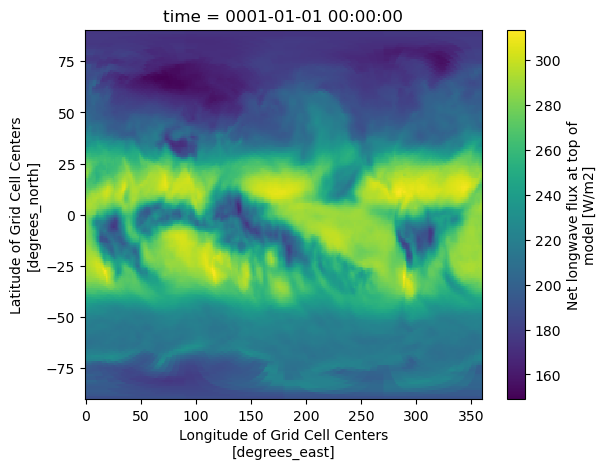

In [12]:
olr['FLNT'].isel(time=0).plot()

## slice to tropical pacific

In [13]:
olr_tp = olr['FLNT'].sel(lat=slice(-10, 10), lon=slice(130, 280))

In [14]:
olr_tp

<xarray.DataArray 'FLNT' (time: 6000, lat: 22, lon: 121)> Size: 64MB
dask.array<getitem, shape=(6000, 22, 121), dtype=float32, chunksize=(1, 22, 121), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
  * lon      (lon) float64 968B 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              W/m2
    long_name:          Net longwave flux at top of model
    cell_methods:       time: mean
    cell_measures:      area: area

In [15]:
olr_tp.shape

(6000, 22, 121)

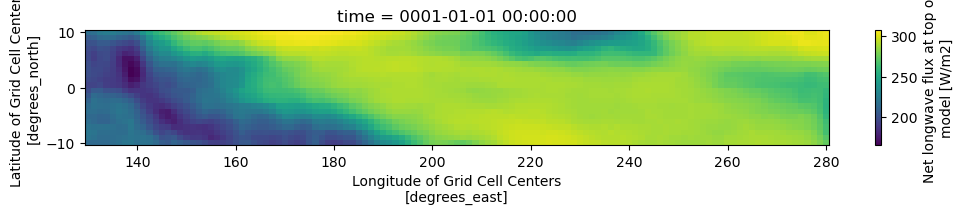

In [16]:
olr_tp[0].plot.pcolormesh(figsize=(12, 1.5))

In [17]:
# check if any NaNs and how many 
has_nan = olr_tp.isnull().any()
print(has_nan.values)

False


## olr climatology

In [18]:
olr_climatology = olr_tp.groupby('time.month').mean(dim='time',
                                                 keep_attrs=True)

In [19]:
olr_climatology

<xarray.DataArray 'FLNT' (month: 12, lat: 22, lon: 121)> Size: 128kB
dask.array<stack, shape=(12, 22, 121), dtype=float32, chunksize=(1, 22, 121), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
  * lon      (lon) float64 968B 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              W/m2
    long_name:          Net longwave flux at top of model
    cell_methods:       time: mean
    cell_measures:      area: area

In [20]:
olr_anomalies = olr_tp.groupby('time.month') - olr_climatology

/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/xarray/core/indexing.py:1621: PerformanceWarning: Slicing with an out-of-order index is generating 500 times more chunks
  return self.array[key]


In [21]:
olr_anomalies

<xarray.DataArray 'FLNT' (time: 6000, lat: 22, lon: 121)> Size: 64MB
dask.array<sub, shape=(6000, 22, 121), dtype=float32, chunksize=(1, 22, 121), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
  * lon      (lon) float64 968B 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

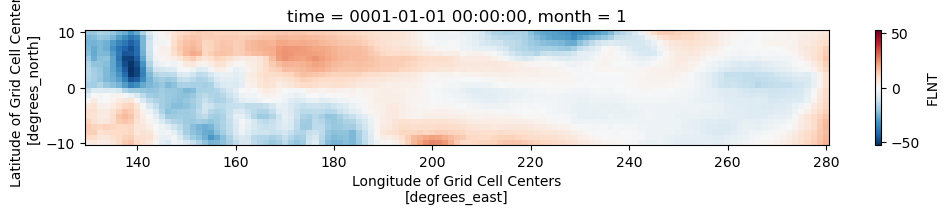

In [22]:
olr_anomalies[0].plot.pcolormesh(figsize=(12, 1.5), cmap='RdBu_r')

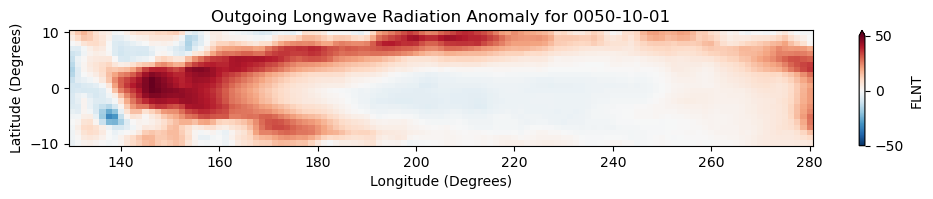

In [23]:
olr_anomalies[597].plot.pcolormesh(figsize=(12, 1.5), vmin=-50, vmax=50, cmap='RdBu_r')
plt.title('Outgoing Longwave Radiation Anomaly for 0050-10-01')
plt.xlabel('Longitude (Degrees)')
plt.ylabel('Latitude (Degrees)')

#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/agufigs/olrinput_sliced.pdf', bbox_inches='tight')
plt.show()

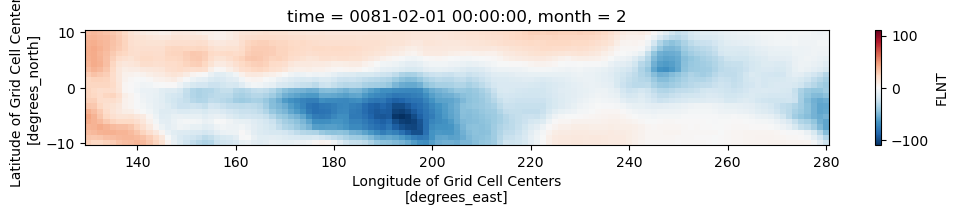

In [24]:
olr_anomalies[961].plot.pcolormesh(figsize=(12, 1.5), cmap='RdBu_r')

## check for trend

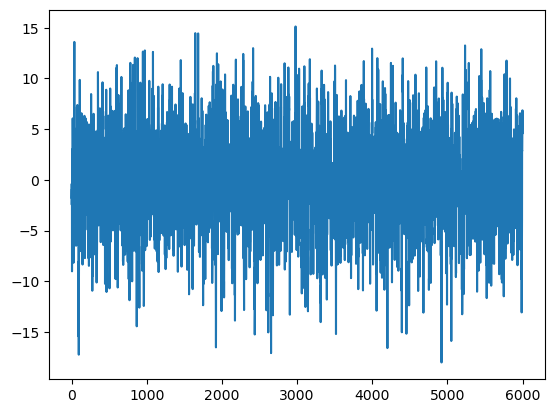

In [25]:
plt.plot(range(0,6000), olr_anomalies.mean(dim=['lat','lon']))
plt.show()

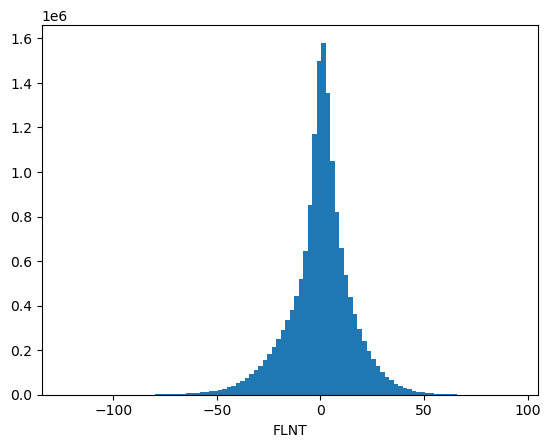

In [26]:
olr_anomalies.stack(newdim=['time', 'lon', 'lat']).plot.hist(bins=100)
plt.show()

In [27]:
print(olr_anomalies.min().values, olr_anomalies.max().values)

-123.50755 93.97978


## How to do grid reconstruction [from Maria]

In [28]:
def create_index_mask(da):
    """
    Create index mask for reconstruction of predictions.
    Args:
        da (xarray data array): 2d input variable samples
    Returns:
        y_, x_ (numpy arrays): x and y indices for reconstruction
    """
    # just one sample needed; time=0
    da = da.isel(time=0)
    
    # original 2d grid shape
    orig_2d_shape = da.shape
    
    # location of the valid values (not nan) in 1d vector
    orig_indx = np.where(~np.isnan(da.stack(newdim=['lat', 'lon']).values))[0]
    
    # Indices of non-nan values in original 2d grid
    y_, x_ = np.unravel_index(orig_indx, orig_2d_shape)
    
    # return the respective indices for (20, 150)
    return y_, x_

def reconstruct_grid(pred_1d, y_indx, x_indx):
    """
    Reconstruct the original 2d grid using NN predictions.
    Args:
        pred_1d (xarray data array): predictions (samples, 1d values)
        y_indx (numpy array): latitude indices for grid (20)
        x_indx (numpy array): longitude indices for grid (150)
    Returns:
        pred_grid (numpy array): predictions on original 2d grid
    """
    # number of predicted samples (!assuming axis=0!)
    n_samples = pred_1d.shape[0]
    
    # grid to be populated with predicted data
    pred_grid = np.full((n_samples, 22, 121), np.nan)
    
    # fill the reconstructed grid
    pred_grid[:, y_indx, x_indx] = pred_1d.values
    
    # return predictions on original 2d grid
    return pred_grid

In [29]:
# produce the indices to be used
y_vals, x_vals = create_index_mask(olr_anomalies)

# save the numpy arrays of the y, x indices
np.save('olr_yindx.npy', y_vals)
np.save('olr_xindx.npy', x_vals)

In [30]:
# indices can be loaded anytime and used for reconstruction
yindx = np.load('olr_yindx.npy')
xindx = np.load('olr_xindx.npy')

### fake predictions here just using actual data
# flattened grid shape
olr_newdim = olr_anomalies.stack(newdim=['lat', 'lon'])
# flattened grid shape after dropping nans
olr_processed = olr_newdim.dropna('newdim', how='any')

# now reconstruct fake predictions
predictions_2d = reconstruct_grid(olr_processed, yindx, xindx)

# can close files like this
del yindx
del xindx

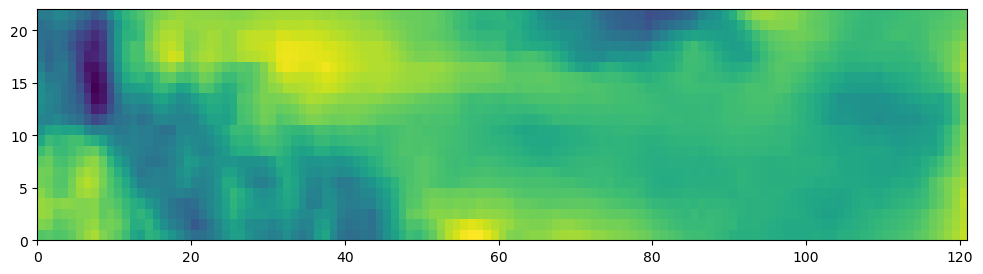

In [31]:
plt.figure(figsize=(12,3))
plt.pcolormesh(predictions_2d[0,:,:])
plt.show()

## checks

In [32]:
olr_newdim = olr_anomalies.stack(newdim=['lat', 'lon'])

In [33]:
olr_newdim.shape

(6000, 2662)

In [34]:
olr_newdim

<xarray.DataArray 'FLNT' (time: 6000, newdim: 2662)> Size: 64MB
dask.array<reshape, shape=(6000, 2662), dtype=float32, chunksize=(1, 2662), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * newdim   (newdim) object 21kB MultiIndex
  * lat      (newdim) float64 21kB -9.895 -9.895 -9.895 ... 9.895 9.895 9.895
  * lon      (newdim) float64 21kB 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0

In [35]:
has_nan_2 = olr_newdim.isnull().any().compute().item()

In [36]:
has_nan_2

False

## drop NaN anyways just in case

In [37]:
olr_processed = olr_newdim.dropna('newdim', how="all")
olr_processed = olr_newdim.dropna('newdim', how="any")

In [38]:
print(olr_processed.shape)

(6000, 2662)


In [39]:
olr_processed

<xarray.DataArray 'FLNT' (time: 6000, newdim: 2662)> Size: 64MB
dask.array<getitem, shape=(6000, 2662), dtype=float32, chunksize=(1, 2662), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * newdim   (newdim) object 21kB MultiIndex
  * lat      (newdim) float64 21kB -9.895 -9.895 -9.895 ... 9.895 9.895 9.895
  * lon      (newdim) float64 21kB 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0

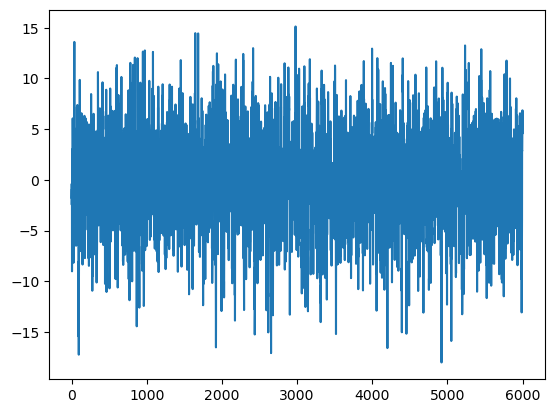

In [40]:
plt.plot(range(0,6000), olr_processed.mean(dim=['newdim']))
plt.show()

## Random train/test split

In [41]:
olr_train, olr_test = train_test_split(
    olr_processed, test_size=0.2, random_state=0, shuffle=True
)

In [42]:
print(olr_train.shape, olr_test.shape)

(4800, 2662) (1200, 2662)


In [43]:
olr_train.values

array([[ -1.0744629 ,  -1.3369141 ,  -0.62908936, ..., -13.566895  ,
        -21.674057  , -21.536407  ],
       [  8.103973  ,   7.81369   ,   7.8527527 , ..., -14.309189  ,
        -19.934143  , -19.520813  ],
       [-19.23375   , -13.197937  ,  -9.148499  , ...,   4.914093  ,
          6.5057373 ,   8.037964  ],
       ...,
       [ -5.3779297 ,  -5.5621033 ,  -6.0236206 , ...,   4.695282  ,
         10.293076  ,  13.040451  ],
       [ 31.128311  ,  35.06595   ,  38.91118   , ...,  -4.952881  ,
         -4.0930176 ,  -4.085663  ],
       [  0.14901733,  -1.1842041 ,  -0.95544434, ...,   1.6397552 ,
          8.296127  ,  13.26503   ]], dtype=float32)

## use robust scaler

In [45]:
# try robust scaler? 
from sklearn.preprocessing import RobustScaler

olr_train_tmp = olr_train.copy()
olr_train_tmp = olr_train_tmp.values

scaler_tmp = RobustScaler()
scaler_tmp_olr = scaler_tmp.fit(olr_train_tmp.reshape(4800 * 2662, 1))

In [46]:
scaler = RobustScaler()
scaler_olr = scaler.fit(olr_train)

In [47]:
scaler_olr.center_ = np.repeat(scaler_tmp_olr.center_, 2662)

In [48]:
scaler_olr.center_

array([0.8749695, 0.8749695, 0.8749695, ..., 0.8749695, 0.8749695,
       0.8749695], dtype=float32)

In [49]:
scaler_olr.scale_ = np.repeat(scaler_tmp_olr.scale_, 2662)

In [50]:
scaler_olr.scale_

array([14.34195328, 14.34195328, 14.34195328, ..., 14.34195328,
       14.34195328, 14.34195328])

In [51]:
scaled_input_olr_train = scaler_olr.transform(olr_train)

scaled_input_olr_test = scaler_olr.transform(olr_test)

print(scaled_input_olr_train.shape, scaled_input_olr_test.shape)

(4800, 2662) (1200, 2662)


In [54]:
import joblib

# Save the scaler to a file
joblib.dump(scaler_olr, 'scaler_olr.pkl')

print("Scaler saved successfully!")

Scaler saved successfully!


In [52]:
scaled_input_olr_train[:10]

array([[-0.13592516, -0.15422471, -0.10487127, ..., -1.0069664 ,
        -1.5722424 , -1.5626447 ],
       [ 0.50404596,  0.48380584,  0.4865295 , ..., -1.0587232 ,
        -1.450926  , -1.4221063 ],
       [-1.4020907 , -0.9812406 , -0.6988914 , ...,  0.28162995,
         0.39260817,  0.49944344],
       ...,
       [-2.23494   , -2.0284998 , -2.0067246 , ..., -0.69058853,
        -0.4744837 , -0.09201477],
       [ 0.03300727, -0.19273035, -0.47158346, ...,  0.36852723,
         0.2973537 ,  0.27511233],
       [ 0.46322525,  0.5095593 ,  0.54607534, ...,  0.74676704,
         1.0181216 ,  0.8303768 ]], dtype=float32)

In [53]:
scaled_input_olr_test[:10]

array([[ 0.52556074, -0.23885795, -0.767553  , ...,  0.5268225 ,
         0.5958799 ,  0.6660842 ],
       [-1.689351  , -1.8238195 , -1.9905518 , ..., -0.39704898,
        -0.3661653 , -0.29747608],
       [-0.14711343,  0.11323267,  0.25455514, ..., -0.13950421,
        -0.15720583, -0.12446667],
       ...,
       [-2.3670883 , -2.3057327 , -2.238717  , ...,  0.7843056 ,
         0.62981063,  0.50421196],
       [ 0.36223942,  0.14286835, -0.05187282, ..., -0.005176  ,
         0.3642694 ,  0.28665167],
       [-0.8217473 , -0.8962371 , -0.7827076 , ..., -0.10742576,
         0.38126245,  0.8151605 ]], dtype=float32)

In [61]:
olr_revert = scaler_olr.inverse_transform(scaled_input_olr_train)

In [62]:
olr_revert

array([[ -1.0744629 ,  -1.3369141 ,  -0.62908936, ..., -13.566895  ,
        -21.674057  , -21.536407  ],
       [  8.103973  ,   7.81369   ,   7.8527527 , ..., -14.309189  ,
        -19.934143  , -19.520813  ],
       [-19.23375   , -13.197937  ,  -9.148499  , ...,   4.914093  ,
          6.5057373 ,   8.037964  ],
       ...,
       [ -5.3779297 ,  -5.5621033 ,  -6.0236206 , ...,   4.695282  ,
         10.293076  ,  13.040451  ],
       [ 31.128311  ,  35.06595   ,  38.91118   , ...,  -4.952881  ,
         -4.0930176 ,  -4.085663  ],
       [  0.14901733,  -1.1842039 ,  -0.95544434, ...,   1.6397552 ,
          8.296127  ,  13.26503   ]], dtype=float32)

In [65]:
olr_revert.min()

-123.50755

In [66]:
olr_revert.max()

87.27942

In [58]:
scaled_input_olr_test.max()

7.098319

In [59]:
scaled_input_olr_train.min()

-18.524736

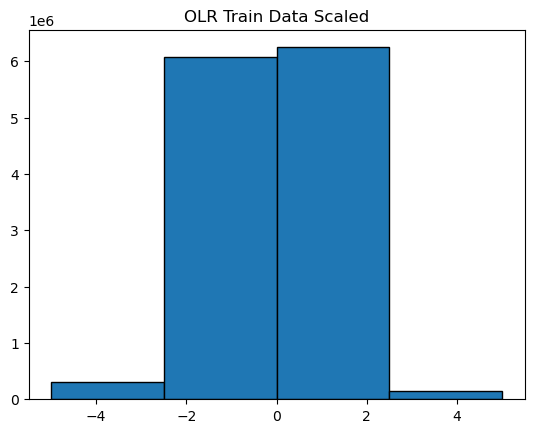

In [55]:
plt.hist(scaled_input_olr_train.flatten(), 
         bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('OLR Train Data Scaled')
plt.show()

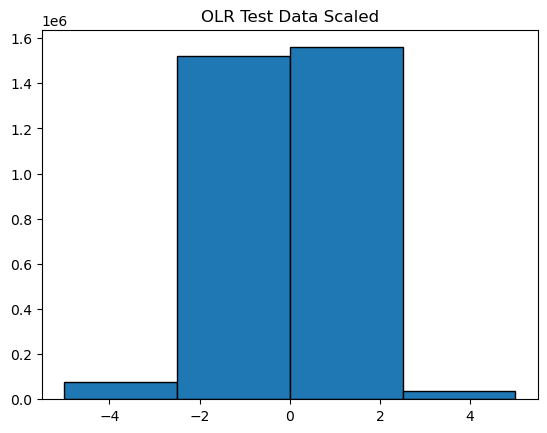

In [56]:
plt.hist(scaled_input_olr_test.flatten(), bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('OLR Test Data Scaled')
plt.show()

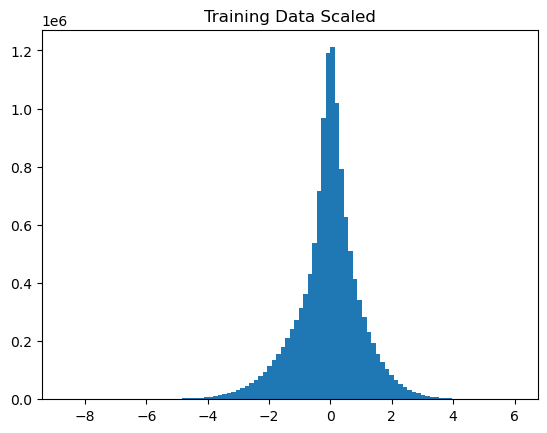

In [57]:
plt.hist(scaled_input_olr_train.flatten(), bins=100)
plt.title('Training Data Scaled')
plt.show()

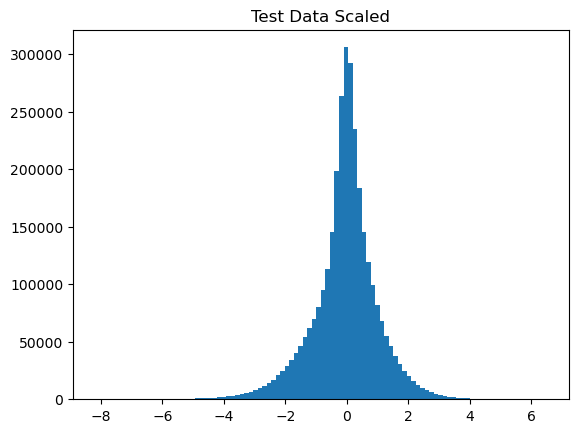

In [58]:
plt.hist(scaled_input_olr_test.flatten(), bins=100)
plt.title('Test Data Scaled')
plt.show()

## RETAIN TIME COMPONENT FOR SORTING LATER

In [60]:
scaled_input_olr_train

array([[-0.12554196, -0.13657615, -0.0938163 , ..., -0.94813424,
        -1.3779582 , -1.2681464 ],
       [ 0.3702252 ,  0.35188618,  0.36871946, ..., -0.9975448 ,
        -1.2715025 , -1.1526399 ],
       [-1.1064038 , -0.76972157, -0.5584007 , ...,  0.28204668,
         0.3462083 ,  0.42665505],
       ...,
       [-0.35799086, -0.36211818, -0.3879934 , ...,  0.2674816 ,
         0.5779347 ,  0.71332973],
       [ 1.6138695 ,  1.806621  ,  2.062412  , ..., -0.37474522,
        -0.30227116, -0.26810664],
       [-0.05945649, -0.12842444, -0.11161324, ...,  0.06409145,
         0.45575243,  0.7261995 ]], dtype=float32)

In [61]:
scaled_input_olr_test

array([[ 0.38689202, -0.20136954, -0.6121011 , ...,  0.51612407,
         0.5245803 ,  0.5636148 ],
       [-1.328936  , -1.4147817 , -1.5686109 , ..., -0.365866  ,
        -0.31961936, -0.22832198],
       [-0.13420917,  0.06818341,  0.18729185, ..., -0.11999639,
        -0.1362563 , -0.08612797],
       ...,
       [-0.7529262 , -0.8888792 , -1.2429606 , ..., -0.6893988 ,
        -0.5515586 , -0.43442872],
       [-1.9574848 , -1.8400195 , -1.8908432 , ..., -0.3386159 ,
        -0.45377693, -0.32345784],
       [ 1.1306046 ,  1.2649598 ,  1.3548496 , ..., -0.57568043,
        -0.5950299 , -0.5587573 ]], dtype=float32)

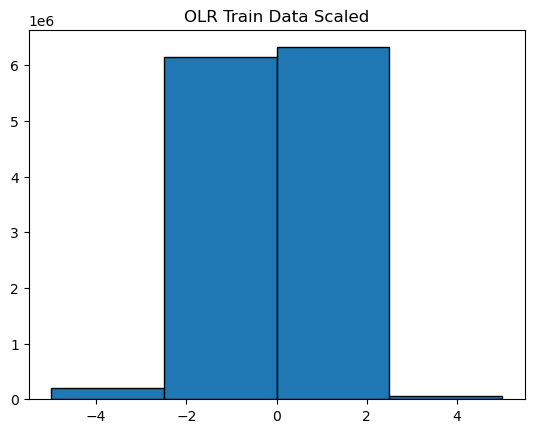

In [62]:
plt.hist(scaled_input_olr_train.flatten(), 
         bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('OLR Train Data Scaled')
plt.show()

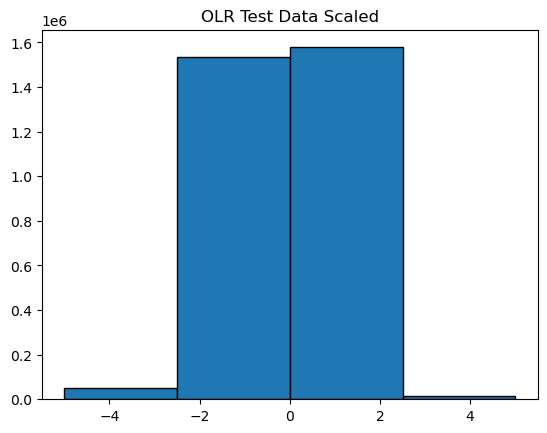

In [63]:
plt.hist(scaled_input_olr_test.flatten(), 
         bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('OLR Test Data Scaled')
plt.show()

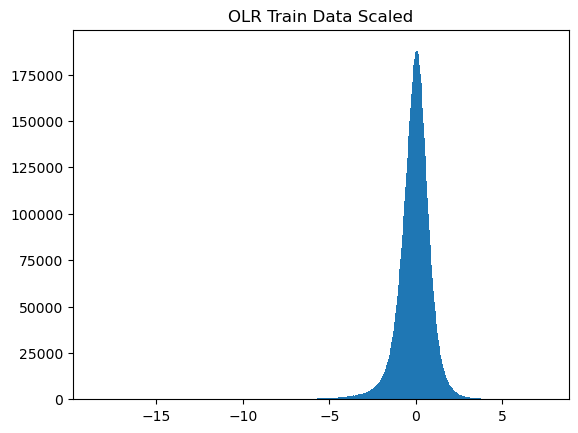

In [64]:
plt.hist(
    scaled_input_olr_train.flatten(),
    bins=1000,
)
plt.title('OLR Train Data Scaled')
plt.show()

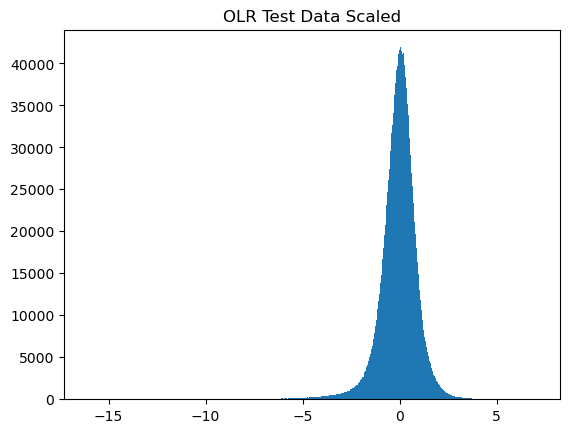

In [65]:
plt.hist(
    scaled_input_olr_test.flatten(),
    bins=1000,
)
plt.title('OLR Test Data Scaled')
plt.show()

In [59]:
import xarray as xr

# Get original coordinates for each dimension
coords = olr_train.coords  # Retains 'time', 'lat', 'lon', etc.
dims = olr_train.dims      # Keeps the dimensions as ('newdim',)

# Create a new DataArray with the scaled data and the original coordinates
olr_train_coords = xr.DataArray(scaled_input_olr_train, dims=dims, coords=coords)

In [60]:
olr_train_coords

<xarray.DataArray (time: 4800, newdim: 2662)> Size: 51MB
array([[-0.13592516, -0.15422471, -0.10487127, ..., -1.0069664 ,
        -1.5722424 , -1.5626447 ],
       [ 0.50404596,  0.48380584,  0.4865295 , ..., -1.0587232 ,
        -1.450926  , -1.4221063 ],
       [-1.4020907 , -0.9812406 , -0.6988914 , ...,  0.28162995,
         0.39260817,  0.49944344],
       ...,
       [-0.43598658, -0.4488282 , -0.4810077 , ...,  0.26637325,
         0.65668225,  0.8482444 ],
       [ 2.1094296 ,  2.3839834 ,  2.6520941 , ..., -0.40634984,
        -0.34639543, -0.34588262],
       [-0.05061738, -0.14357692, -0.12762654, ...,  0.05332508,
         0.517444  ,  0.8639033 ]], dtype=float32)
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
  * newdim   (newdim) object 21kB MultiIndex
  * lat      (newdim) float64 21kB -9.895 -9.895 -9.895 ... 9.895 9.895 9.895
  * lon      (newdim) float64 21kB 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0

In [61]:
import xarray as xr

# Get original coordinates for each dimension
coords = olr_test.coords  # Retains 'time', 'lat', 'lon', etc.
dims = olr_test.dims      # Keeps the dimensions as ('newdim',)

# Create a new DataArray with the scaled data and the original coordinates
olr_test_coords = xr.DataArray(scaled_input_olr_test, dims=dims, coords=coords)

In [62]:
olr_test_coords

<xarray.DataArray (time: 1200, newdim: 2662)> Size: 13MB
array([[ 0.52556074, -0.23885795, -0.767553  , ...,  0.5268225 ,
         0.5958799 ,  0.6660842 ],
       [-1.689351  , -1.8238195 , -1.9905518 , ..., -0.39704898,
        -0.3661653 , -0.29747608],
       [-0.14711343,  0.11323267,  0.25455514, ..., -0.13950421,
        -0.15720583, -0.12446667],
       ...,
       [-0.9457969 , -1.1368846 , -1.5741733 , ..., -0.7359448 ,
        -0.63048196, -0.54824895],
       [-2.500726  , -2.379266  , -2.4025595 , ..., -0.36850488,
        -0.51905054, -0.4132292 ],
       [ 1.4855973 ,  1.6764647 ,  1.7474009 , ..., -0.6168265 ,
        -0.6800216 , -0.69952124]], dtype=float32)
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
  * newdim   (newdim) object 21kB MultiIndex
  * lat      (newdim) float64 21kB -9.895 -9.895 -9.895 ... 9.895 9.895 9.895
  * lon      (newdim) float64 21kB 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0

In [63]:
print(olr_train_coords.shape, olr_test_coords.shape)

(4800, 2662) (1200, 2662)


In [64]:
# Convert MultiIndex levels in `newdim` into separate coordinates
olr_train_reset_index = olr_train_coords.reset_index('newdim')

In [65]:
olr_train_reset_index

<xarray.DataArray (time: 4800, newdim: 2662)> Size: 51MB
array([[-0.13592516, -0.15422471, -0.10487127, ..., -1.0069664 ,
        -1.5722424 , -1.5626447 ],
       [ 0.50404596,  0.48380584,  0.4865295 , ..., -1.0587232 ,
        -1.450926  , -1.4221063 ],
       [-1.4020907 , -0.9812406 , -0.6988914 , ...,  0.28162995,
         0.39260817,  0.49944344],
       ...,
       [-0.43598658, -0.4488282 , -0.4810077 , ...,  0.26637325,
         0.65668225,  0.8482444 ],
       [ 2.1094296 ,  2.3839834 ,  2.6520941 , ..., -0.40634984,
        -0.34639543, -0.34588262],
       [-0.05061738, -0.14357692, -0.12762654, ...,  0.05332508,
         0.517444  ,  0.8639033 ]], dtype=float32)
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
    lat      (newdim) float64 21kB -9.895 -9.895 -9.895 ... 9.895 9.895 9.895
    lon      (newdim) float64 21kB 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0
Dimensions without coordinates: newdim

In [66]:
# Convert MultiIndex levels in `newdim` into separate coordinates
olr_test_reset_index = olr_test_coords.reset_index('newdim')

In [67]:
olr_test_reset_index

<xarray.DataArray (time: 1200, newdim: 2662)> Size: 13MB
array([[ 0.52556074, -0.23885795, -0.767553  , ...,  0.5268225 ,
         0.5958799 ,  0.6660842 ],
       [-1.689351  , -1.8238195 , -1.9905518 , ..., -0.39704898,
        -0.3661653 , -0.29747608],
       [-0.14711343,  0.11323267,  0.25455514, ..., -0.13950421,
        -0.15720583, -0.12446667],
       ...,
       [-0.9457969 , -1.1368846 , -1.5741733 , ..., -0.7359448 ,
        -0.63048196, -0.54824895],
       [-2.500726  , -2.379266  , -2.4025595 , ..., -0.36850488,
        -0.51905054, -0.4132292 ],
       [ 1.4855973 ,  1.6764647 ,  1.7474009 , ..., -0.6168265 ,
        -0.6800216 , -0.69952124]], dtype=float32)
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
    lat      (newdim) float64 21kB -9.895 -9.895 -9.895 ... 9.895 9.895 9.895
    lon      (newdim) float64 21kB 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0
Dimensions without coordinates: newdim

In [68]:
# Save the xarray DataArray to a NetCDF file
olr_train = olr_train_reset_index.to_netcdf('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_train_robustscaler.nc')
olr_test = olr_test_reset_index.to_netcdf('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_test_robustscaler.nc')

In [69]:
from numpy import asarray
from numpy import savetxt
from numpy import genfromtxt

In [70]:
# olr train and test
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_train_robustscaler.csv',
        scaled_input_olr_train, delimiter=',')
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_test_robustscaler.csv',
        scaled_input_olr_test, delimiter=',')

## autoencoder test

In [207]:
tf.random.set_seed(1)

In [208]:
input_shape_olr = scaled_input_olr_train.shape[1]
print(input_shape_olr)

2662


In [209]:
# olr1 input
input_olr_1 = Input(shape=(np.int64(input_shape_olr),), name='input_olr_1')
print(input_olr_1.shape)

# add 2 dense layers
encoded_olr_1_layer1 = Dense(50, activation='elu')(input_olr_1)
encoded_olr_1_layer2 = Dense(25, activation='elu')(encoded_olr_1_layer1)
encoded_olr_1_layer3 = Dense(10, activation='elu')(encoded_olr_1_layer2)

# ssh input
input_olr_2 = Input(shape=(np.int64(input_shape_olr),), name='input_olr_2')
print(input_olr_2.shape)

# add 2 dense layers (again)
encoded_olr_2_layer1 = Dense(50, activation='elu')(input_olr_2)
encoded_olr_2_layer2 = Dense(25, activation='elu')(encoded_olr_2_layer1)
encoded_olr_2_layer3 = Dense(10, activation='elu')(encoded_olr_2_layer2)

# zonal stress input 
# ssh input
input_olr_3 = Input(shape=(np.int64(input_shape_olr),), name='input_olr_3')
print(input_olr_3.shape)

# add 2 dense layers (again)
encoded_olr_3_layer1 = Dense(50, activation='elu')(input_olr_3)
encoded_olr_3_layer2 = Dense(25, activation='elu')(encoded_olr_3_layer1)
encoded_olr_3_layer3 = Dense(10, activation='elu')(encoded_olr_3_layer2)

(None, 2662)
(None, 2662)
(None, 2662)


In [210]:
# add concatenation layer
# merge 3 input fields
bottleneck = keras.layers.concatenate(
    [encoded_olr_1_layer3, encoded_olr_2_layer3, encoded_olr_3_layer3])
bottleneck1 = Dense(1, activation='elu')(bottleneck)
print(bottleneck1)

# build decoder for each variable from the bottleneck
# sst
decoded_olr_1_layer1 = Dense(10, activation='elu')(bottleneck1)
decoded_olr_1_layer2 = Dense(25, activation='elu')(decoded_olr_1_layer1)
decoded_olr_1_layer3 = Dense(50, activation='elu')(decoded_olr_1_layer2)
output_olr_1 = Dense(np.int64(input_shape_olr), activation='linear',
                     name='output_olr_1')(decoded_olr_1_layer3)
print(output_olr_1.shape)

# build decoder for each variable from the bottleneck
# ssh
decoded_olr_2_layer1 = Dense(10, activation='elu')(bottleneck1)
decoded_olr_2_layer2 = Dense(25, activation='elu')(decoded_olr_2_layer1)
decoded_olr_2_layer3 = Dense(50, activation='elu')(decoded_olr_2_layer2)
output_olr_2 = Dense(np.int64(input_shape_olr), activation='linear',
                     name='output_olr_2')(decoded_olr_2_layer3)
print(output_olr_2.shape)

# build decoder for each variable from the bottleneck
# zonal stress
decoded_olr_3_layer1 = Dense(10, activation='elu')(bottleneck1)
decoded_olr_3_layer2 = Dense(25, activation='elu')(decoded_olr_3_layer1)
decoded_olr_3_layer3 = Dense(50, activation='elu')(decoded_olr_3_layer2)
output_olr_3 = Dense(np.int64(input_shape_olr), activation='linear',
                     name='output_olr_3')(decoded_olr_3_layer3)
print(output_olr_3.shape)

KerasTensor(type_spec=TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), name='dense_247/Elu:0', description="created by layer 'dense_247'")
(None, 2662)
(None, 2662)
(None, 2662)


In [211]:
# only using lists
# maps inputs to outputs
enso_model = Model(inputs=[input_olr_1, input_olr_2, input_olr_3],
                   outputs=[output_olr_1, output_olr_2, output_olr_3])

# compile the model using lists
opt = keras.optimizers.Adam(learning_rate=0.00075)
enso_model.compile(optimizer=opt,
                   loss='mean_squared_error',
                   metrics=['accuracy']
                  )

In [212]:
enso_model.summary()

Model: "model_13"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_olr_1 (InputLayer)    [(None, 2662)]               0         []                            
                                                                                                  
 input_olr_2 (InputLayer)    [(None, 2662)]               0         []                            
                                                                                                  
 input_olr_3 (InputLayer)    [(None, 2662)]               0         []                            
                                                                                                  
 dense_238 (Dense)           (None, 50)                   133150    ['input_olr_1[0][0]']         
                                                                                           

In [213]:
# train the model!
enso_model_history = enso_model.fit(x=[scaled_input_olr_train,
                                       scaled_input_olr_train,
                                       scaled_input_olr_train],
                                    y=[scaled_input_olr_train,
                                       scaled_input_olr_train,
                                       scaled_input_olr_train],
                                    epochs=100,
                                    batch_size=256,
                                    validation_split=0.3
                                   )

Epoch 1/100
14/14 [==============================] - 3s 56ms/step - loss: 2.8622 - output_olr_1_loss: 0.9547 - output_olr_2_loss: 0.9541 - output_olr_3_loss: 0.9534 - output_olr_1_accuracy: 0.0000e+00 - output_olr_2_accuracy: 2.9762e-04 - output_olr_3_accuracy: 0.0018 - val_loss: 2.9174 - val_output_olr_1_loss: 0.9747 - val_output_olr_2_loss: 0.9731 - val_output_olr_3_loss: 0.9696 - val_output_olr_1_accuracy: 0.0000e+00 - val_output_olr_2_accuracy: 0.0021 - val_output_olr_3_accuracy: 0.0021
Epoch 2/100
14/14 [==============================] - 0s 16ms/step - loss: 2.6768 - output_olr_1_loss: 0.8943 - output_olr_2_loss: 0.8905 - output_olr_3_loss: 0.8919 - output_olr_1_accuracy: 2.9762e-04 - output_olr_2_accuracy: 5.9524e-04 - output_olr_3_accuracy: 5.9524e-04 - val_loss: 2.7421 - val_output_olr_1_loss: 0.9166 - val_output_olr_2_loss: 0.9085 - val_output_olr_3_loss: 0.9170 - val_output_olr_1_accuracy: 6.9444e-04 - val_output_olr_2_accuracy: 0.0000e+00 - val_output_olr_3_accuracy: 0.0000e

In [214]:
from keras.callbacks import History
tf.keras.callbacks.History()

# print dictionary keys
print(enso_model_history.history.keys())

# print model parameters
print(enso_model_history.params)

dict_keys(['loss', 'output_olr_1_loss', 'output_olr_2_loss', 'output_olr_3_loss', 'output_olr_1_accuracy', 'output_olr_2_accuracy', 'output_olr_3_accuracy', 'val_loss', 'val_output_olr_1_loss', 'val_output_olr_2_loss', 'val_output_olr_3_loss', 'val_output_olr_1_accuracy', 'val_output_olr_2_accuracy', 'val_output_olr_3_accuracy'])
{'verbose': 1, 'epochs': 100, 'steps': 14}


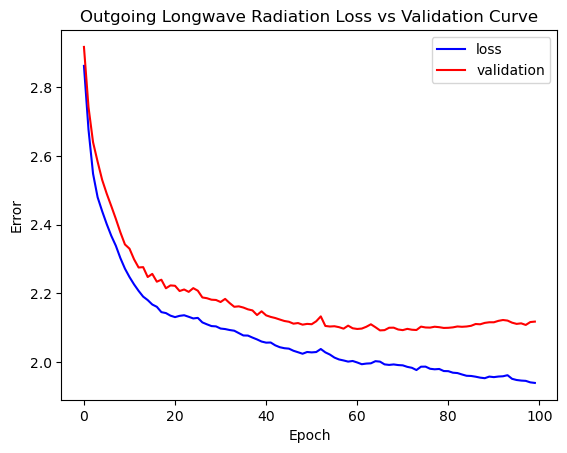

In [215]:
plt.plot(enso_model_history.history['loss'], label='loss', color='blue')
plt.plot(enso_model_history.history['val_loss'], label='validation', color='red')
plt.legend()
plt.title('Outgoing Longwave Radiation Loss vs Validation Curve')
plt.xlabel('Epoch')
plt.ylabel('Error')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/figures/ohconly_0825.png', dpi=350, bbox_inches='tight')
plt.show()

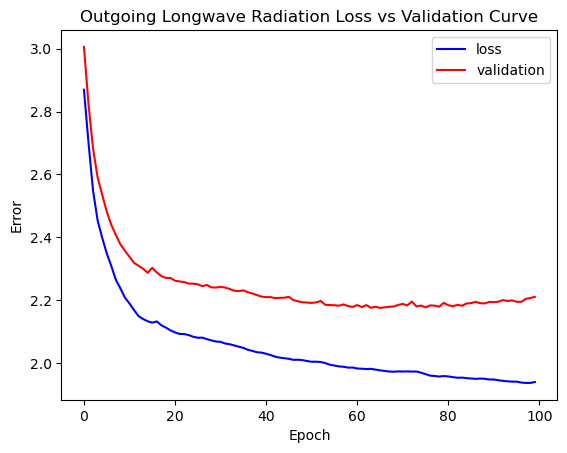

In [206]:
plt.plot(enso_model_history.history['loss'], label='loss', color='blue')
plt.plot(enso_model_history.history['val_loss'], label='validation', color='red')
plt.legend()
plt.title('Outgoing Longwave Radiation Loss vs Validation Curve')
plt.xlabel('Epoch')
plt.ylabel('Error')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/figures/ohconly_0825.png', dpi=350, bbox_inches='tight')
plt.show()

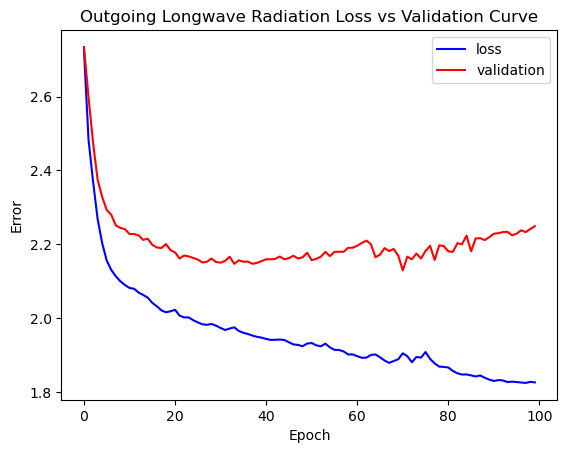

In [195]:
plt.plot(enso_model_history.history['loss'], label='loss', color='blue')
plt.plot(enso_model_history.history['val_loss'], label='validation', color='red')
plt.legend()
plt.title('Outgoing Longwave Radiation Loss vs Validation Curve')
plt.xlabel('Epoch')
plt.ylabel('Error')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/figures/ohconly_0825.png', dpi=350, bbox_inches='tight')
plt.show()

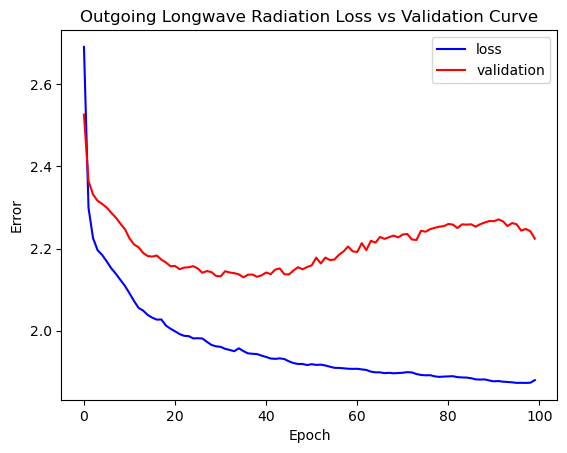

In [186]:
plt.plot(enso_model_history.history['loss'], label='loss', color='blue')
plt.plot(enso_model_history.history['val_loss'], label='validation', color='red')
plt.legend()
plt.title('Outgoing Longwave Radiation Loss vs Validation Curve')
plt.xlabel('Epoch')
plt.ylabel('Error')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/figures/ohconly_0825.png', dpi=350, bbox_inches='tight')
plt.show()

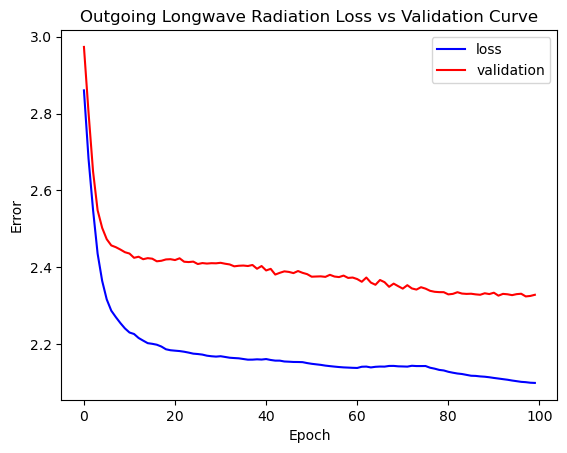

In [175]:
plt.plot(enso_model_history.history['loss'], label='loss', color='blue')
plt.plot(enso_model_history.history['val_loss'], label='validation', color='red')
plt.legend()
plt.title('Outgoing Longwave Radiation Loss vs Validation Curve')
plt.xlabel('Epoch')
plt.ylabel('Error')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/figures/ohconly_0825.png', dpi=350, bbox_inches='tight')
plt.show()